# Problem Title - Interaction pattern study and transformation hypotheses #7
Issue: #7


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Replace with your actual CSV file path
data = pd.read_csv("dataset.csv")

print(data.head())


def predict(X, w, b):
    """
    X: (n_samples, n_features)
    w: (n_features,)
    b: scalar bias
    """
    return X.dot(w) + b


   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Concrete compressive strength  
0            1040.0           676.0   28                          79.99  
1            1055.0           676.0   28                          61.89  
2             932.0           594.0  270                          40.27  
3             932.0           594.0  365                          41.05  
4             978.4           825.5  360                          44.30  


In [5]:
def mse_loss(y_pred, y_true):
    errors = y_pred - y_true
    return np.mean(errors**2)

In [6]:
def compute_gradients(X, y_true, w, b):
    n = X.shape[0]
    y_pred = predict(X, w, b)
    errors = y_pred - y_true

    grad_w = (2/n) * X.T.dot(errors)
    grad_b = (2/n) * np.sum(errors)
    return grad_w, grad_b

In [7]:
def numerical_gradient_check(X, y_true, w, b, epsilon=1e-5):
    grad_w_num = np.zeros_like(w)
    for i in range(len(w)):
        w_plus = w.copy(); w_plus[i] += epsilon
        w_minus = w.copy(); w_minus[i] -= epsilon
        loss_plus = mse_loss(predict(X, w_plus, b), y_true)
        loss_minus = mse_loss(predict(X, w_minus, b), y_true)
        grad_w_num[i] = (loss_plus - loss_minus) / (2*epsilon)

    b_plus = b + epsilon
    b_minus = b - epsilon
    loss_plus = mse_loss(predict(X, w, b_plus), y_true)
    loss_minus = mse_loss(predict(X, w, b_minus), y_true)
    grad_b_num = (loss_plus - loss_minus) / (2*epsilon)

    return grad_w_num, grad_b_num

In [8]:
# Small test data
np.random.seed(42)
X = np.random.randn(5, 3)
y = np.random.randn(5)
w = np.random.randn(3)
b = np.random.randn()

# Compute gradients
grad_w_analytic, grad_b_analytic = compute_gradients(X, y, w, b)
grad_w_num, grad_b_num = numerical_gradient_check(X, y, w, b)

# Error difference
error_w = np.linalg.norm(grad_w_analytic - grad_w_num)
error_b = abs(grad_b_analytic - grad_b_num)

print("Analytic grad_w:", grad_w_analytic)
print("Numeric grad_w:", grad_w_num)
print("Error difference (w):", error_w)

print("Analytic grad_b:", grad_b_analytic)
print("Numeric grad_b:", grad_b_num)
print("Error difference (b):", error_b)

Analytic grad_w: [ 1.49378452 -0.62542294 -0.77824979]
Numeric grad_w: [ 1.49378452 -0.62542294 -0.77824979]
Error difference (w): 1.7936931593503127e-11
Analytic grad_b: 1.2711234726403562
Numeric grad_b: 1.2711234726459075
Error difference (b): 5.551337167730708e-12


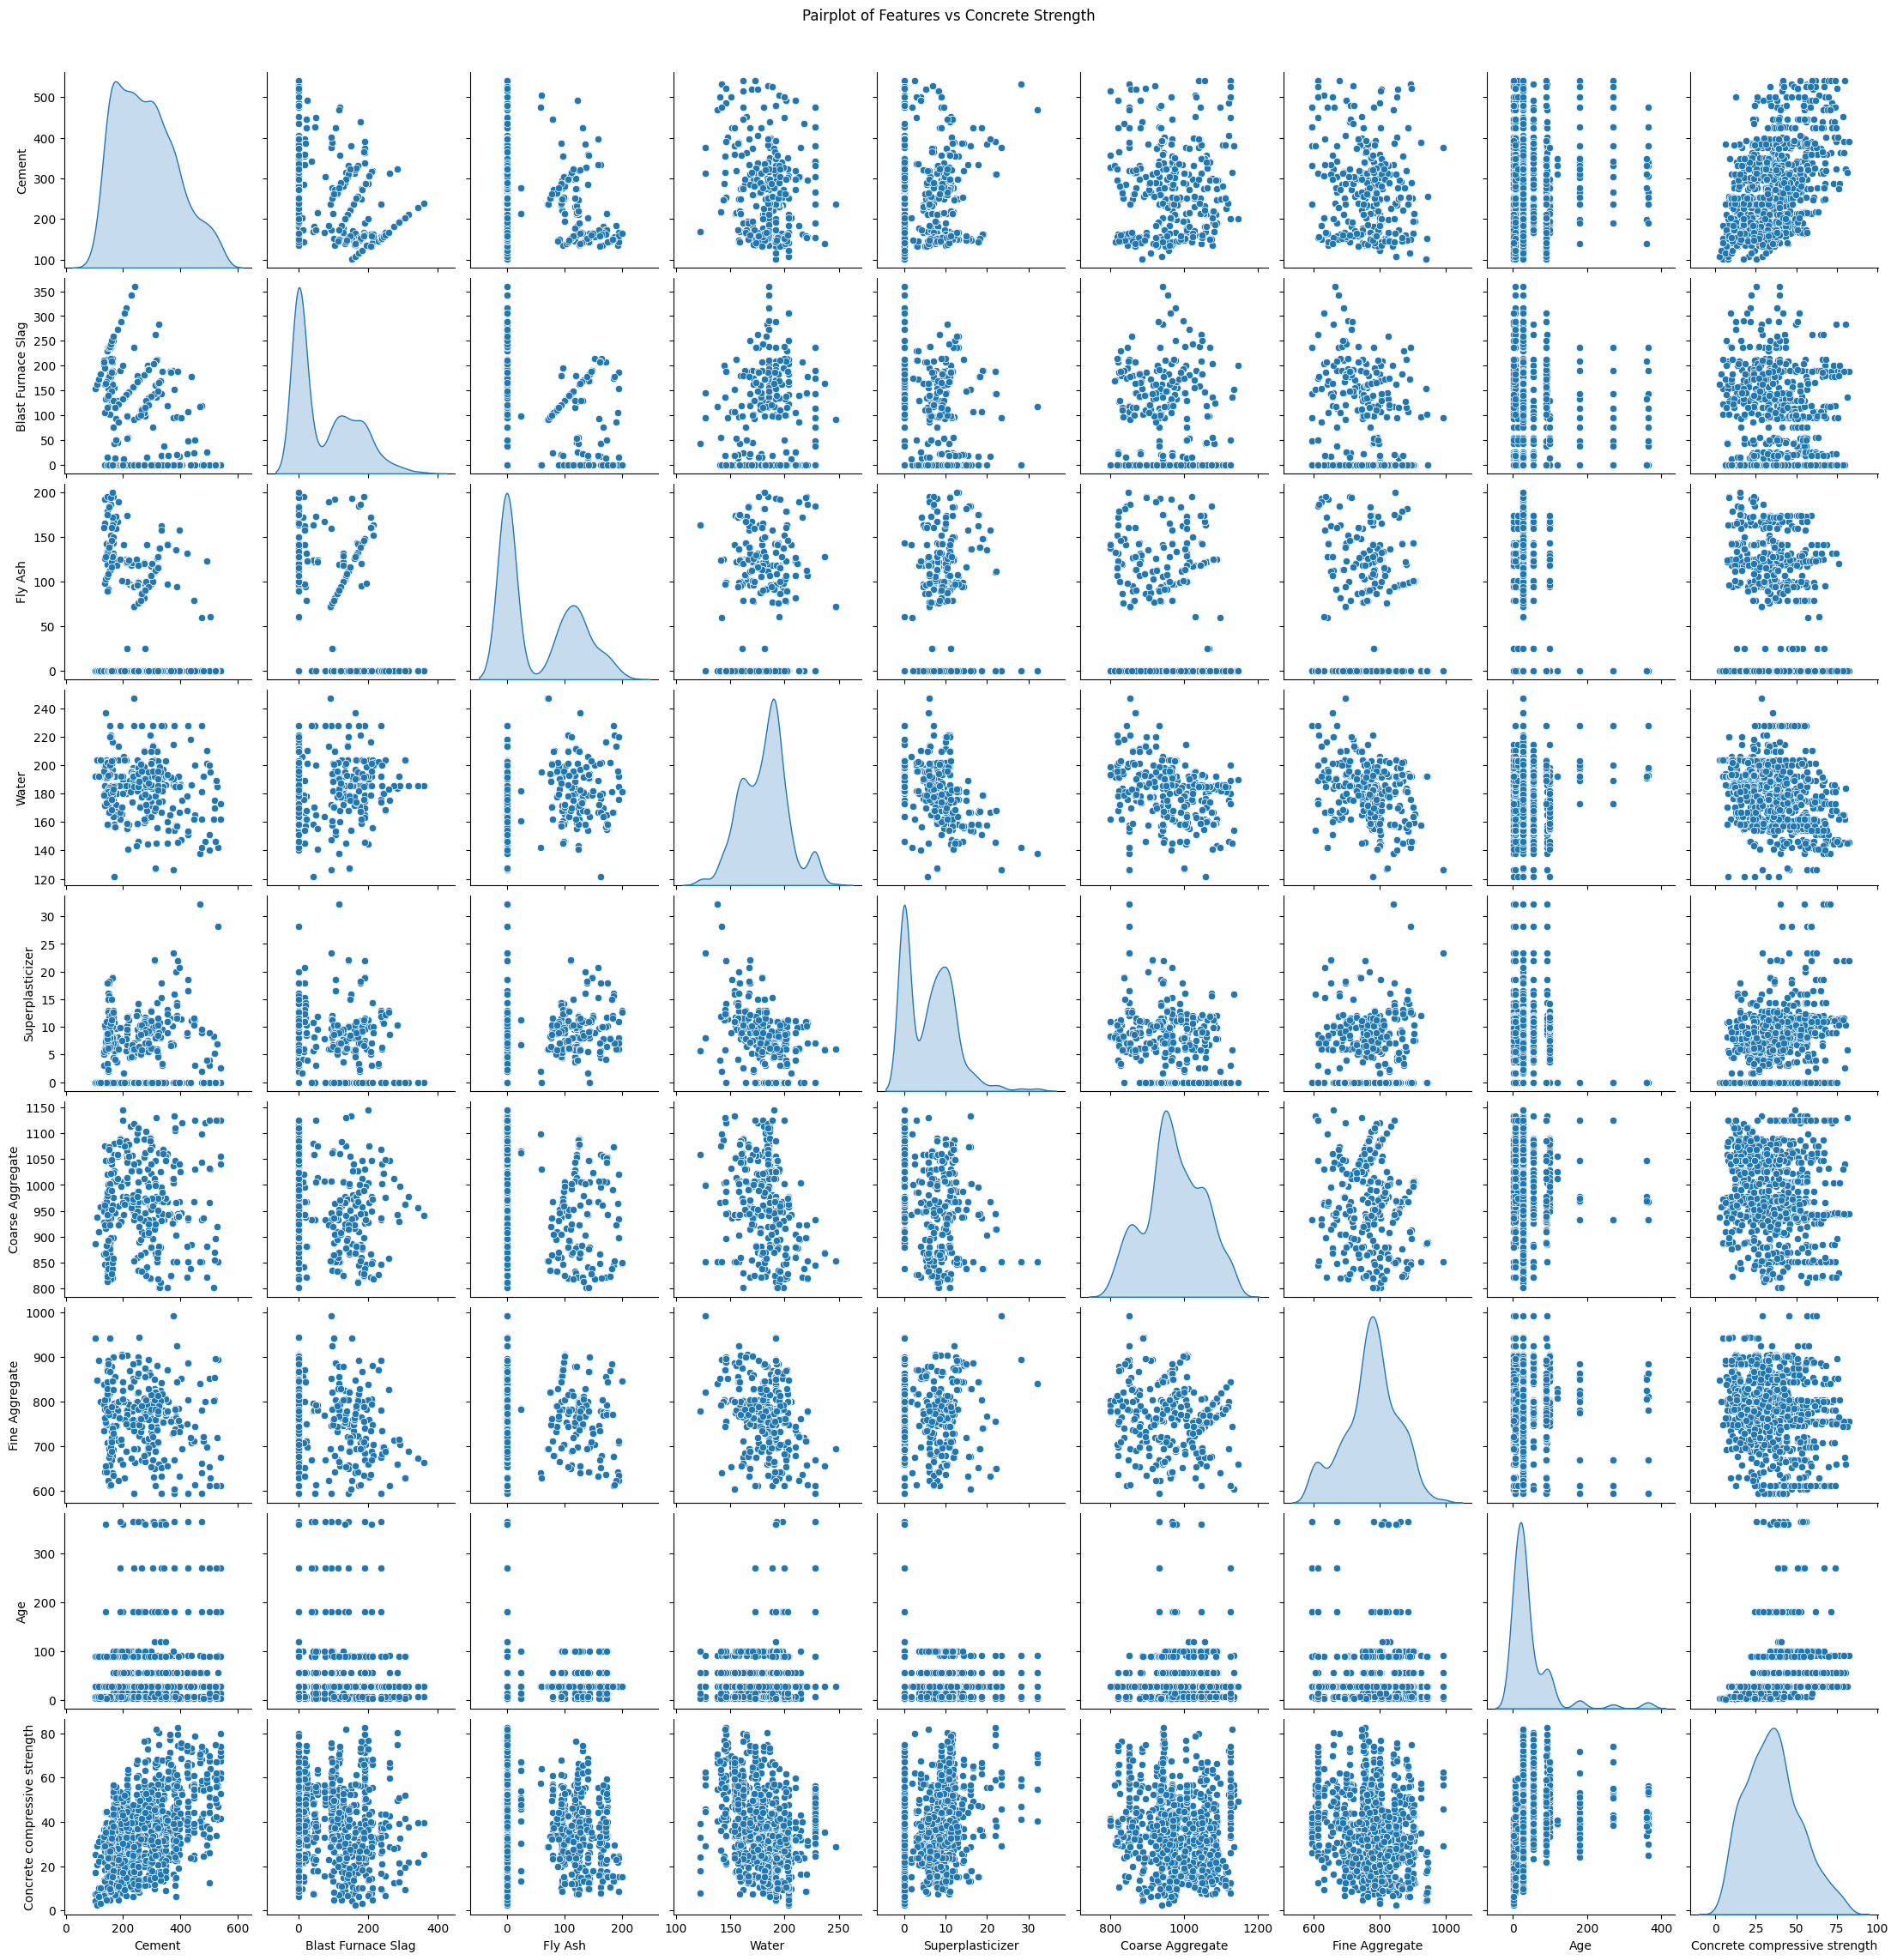

In [9]:
sns.pairplot(data, diag_kind="kde")
plt.suptitle("Pairplot of Features vs Concrete Strength", y=1.02)
plt.show()

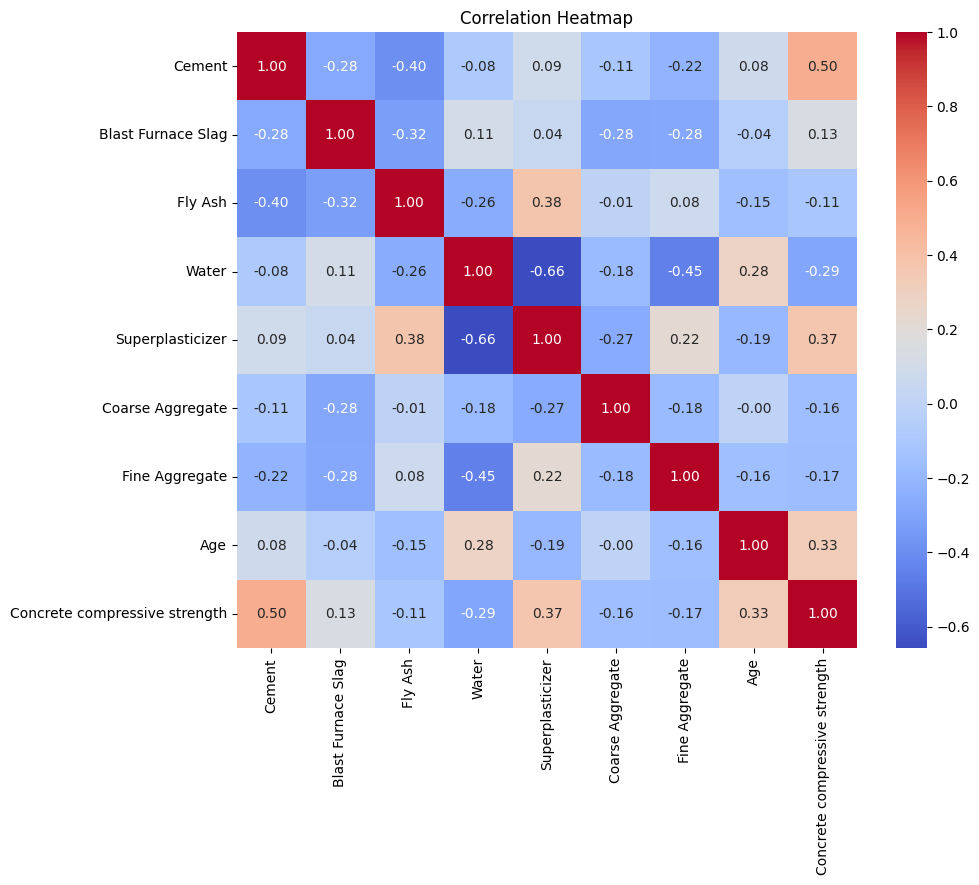

In [10]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

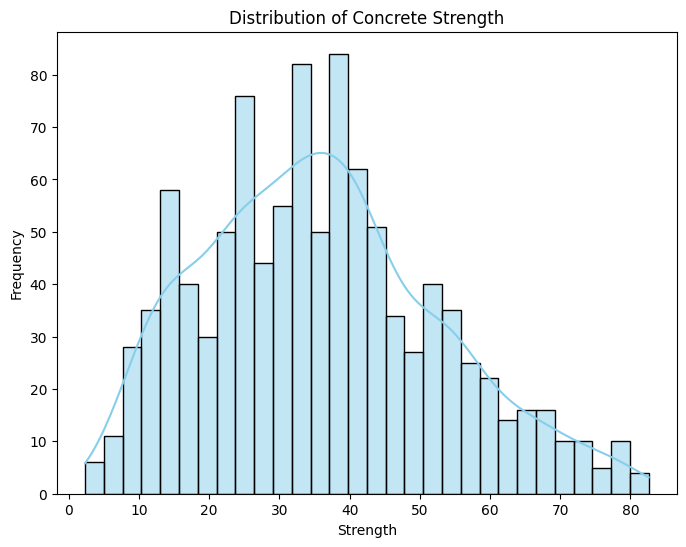

In [11]:
# Distribution of target variable
plt.figure(figsize=(8,6))
sns.histplot(data["Concrete compressive strength"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Concrete Strength")
plt.xlabel("Strength")
plt.ylabel("Frequency")
plt.show()

## 1. Setup and Imports
Import pandas, matplotlib, and seaborn, then configure clean plotting defaults once.

## 2. Load and Inspect Data
Load dataset.csv and quickly check shape, column types, missing values, and sample rows.

## 3. EDA (Distributions and Correlations)
Analyze feature distributions, outliers, and correlations that affect modeling decisions.

## 4. Visualization (Matplotlib/Seaborn)
Create at least three relevant plots and explain what each one reveals.

## 5. Key Observations
Write three to five concise findings linked directly to your EDA and plots.

## 6. Summary
Answer only these exploration-focused questions:
1. What are the top 3 dataset insights from your EDA?

The "Age" of the concrete is the most critical non-linear predictor

Cement is King: Cement is the most important factor. The more cement in the mix, the stronger the concrete becomes (Correlation: 0.50).

The "Chemical Swap": There is a strong trade-off between Water and Superplasticizer. When you use more plasticizer, you need less water to keep the concrete workable, which helps maintain high strength.


2. Which plot gave the strongest insight, and why?

The Strongest Insight: The Heatmap

Correlation Heatmap was the most useful tool. It acted like a "cheat sheet" for the entire dataset. It didn't just show what helps strength (like Cement and Age), but it also revealed hidden redundancies, such as how Water and Fine Aggregates overlap. This tells us exactly which variables the model should focus on and which ones might cause confusion.

3. What data issues or patterns (imbalance, skew, outliers, multicollinearity) did your visualizations reveal?

Outliers: Several extreme values exist in the "Age" and "Water" features

Multicollinearity (Overlapping Info): Water and Superplasticizer are too closely linked (-0.66 correlation). In a simple model, having both can be redundant, like having two clocks in one room—if they don't agree perfectly, the model gets "confused."